# Final XGBoost validation and submission

This notebook completes the team.blue churn assignment after model selection. Logistic regression and XGBoost were compared using the temporal tuning folds, and XGBoost was selected before inspecting the reserved holdout.

The workflow is sequential:

1. Load the frozen XGBoost hyperparameters and classification threshold.
2. Evaluate that exact configuration once on the reserved June 2023 cohort.
3. Refit the pipeline on all labelled training customers.
4. Predict churn for the unlabelled 2024 validation customers.
5. Write and validate the required two-column `predictions.csv`.


## 1. Setup

The notebook delegates loading, feature engineering, preprocessing, and model construction to tested functions in `src/team_blue`. It does not perform hyperparameter search again.

In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from team_blue.data import CUSTOMER_ID_COLUMN, find_project_root
from team_blue.modeling import (
    make_expanding_window_folds,
    make_model_pipeline,
    positive_class_probability,
)
from team_blue.train import load_selected_configuration
from team_blue.workflow import prepare_modeling_data, prepare_training_data

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [2]:
PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

# An environment override is useful for automated execution. In ordinary
# notebook use, the first existing path below is selected.
config_override = os.environ.get("TEAM_BLUE_XGBOOST_CONFIG")
config_candidates = [
    PROJECT_ROOT / "artifacts" / "tuning" / "xgboost" / "best_config.json",
    PROJECT_ROOT / "artifacts" / "tuning" / "xgboost" / "xgboost_best_config.json",
    PROJECT_ROOT / "artifacts" / "tuning" / "xgboost_best_config.json",
]

if config_override:
    CONFIG_PATH = Path(config_override).expanduser().resolve()
else:
    CONFIG_PATH = next(
        (path for path in config_candidates if path.is_file()),
        config_candidates[0],
    )

OUTPUT_DIR = Path(
    os.environ.get("TEAM_BLUE_OUTPUT_DIR", PROJECT_ROOT / "outputs")
).expanduser().resolve()
FINAL_ARTIFACT_DIR = Path(
    os.environ.get(
        "TEAM_BLUE_FINAL_ARTIFACT_DIR",
        PROJECT_ROOT / "artifacts" / "final" / "xgboost",
    )
).expanduser().resolve()

if not CONFIG_PATH.is_file():
    searched = "\n".join(f"- {path}" for path in config_candidates)
    raise FileNotFoundError(
        "Could not find the tuned XGBoost configuration. "
        f"Expected one of:\n{searched}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Configuration: {CONFIG_PATH}")

Project root: /home/jordirm/dev/team-blue-assignment
Configuration: /home/jordirm/dev/team-blue-assignment/artifacts/tuning/xgboost/best_config.json


## 2. Load the frozen model decision

The configuration contains the best parameters found on the tuning folds and the threshold selected from out-of-time tuning probabilities. Neither is changed after viewing the holdout.

In [3]:
configuration_payload = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
configuration = load_selected_configuration(CONFIG_PATH)

assert configuration.model_name == "xgboost", (
    "This notebook is reserved for the selected XGBoost model."
)

configuration_summary = pd.Series(
    {
        "model": configuration.model_name,
        "selection_metric": configuration_payload.get("selection_metric"),
        "best_tuning_score": configuration_payload.get("best_tuning_score"),
        "threshold": configuration.threshold,
        "threshold_metric": configuration_payload.get("threshold_metric"),
        "reserved_holdout_period": configuration_payload.get(
            "reserved_holdout_period",
            configuration_payload.get("holdout_period"),
        ),
    },
    name="selected_configuration",
)
display(configuration_summary.to_frame())
display(
    pd.Series(configuration.parameters, name="value")
    .rename_axis("hyperparameter")
    .to_frame()
)

,selected_configuration
model,xgboost
selection_metric,roc_auc
best_tuning_score,0.7128
threshold,0.6000
threshold_metric,balanced_accuracy
reserved_holdout_period,2023-06


,value
hyperparameter,
colsample_bytree,0.6196
learning_rate,0.0142
max_depth,4.0000
min_child_weight,1.8852
n_estimators,751.0000
reg_alpha,0.0000
reg_lambda,0.0100
subsample,0.8772


## 3. Reconstruct the reserved holdout

Only labelled training data is loaded at this stage. The last expanding-window fold is the untouched holdout; with the supplied cohorts this should be June 2023.

In [4]:
training = prepare_training_data(DATA_DIR)
folds = make_expanding_window_folds(training.cohorts)
holdout_fold = folds[-1]

fold_summary = pd.DataFrame(
    [
        {
            "validation_period": str(fold.validation_period),
            "training_customers": len(fold.train_index),
            "validation_customers": len(fold.validation_index),
            "purpose": "reserved holdout" if fold is holdout_fold else "tuning",
        }
        for fold in folds
    ]
)
display(fold_summary)

recorded_holdout = configuration_payload.get(
    "reserved_holdout_period",
    configuration_payload.get("holdout_period"),
)
if recorded_holdout is not None:
    assert str(holdout_fold.validation_period) == str(recorded_holdout), (
        "The current holdout does not match the period recorded during tuning."
    )

,validation_period,training_customers,validation_customers,purpose
0,2023-04,11945,3464,tuning
1,2023-05,15409,3682,tuning
2,2023-06,19091,3582,reserved holdout


## 4. One-time holdout validation

The frozen pipeline is fitted on all cohorts preceding June and evaluated on June. Training metrics are shown only as an overfitting diagnostic; holdout metrics are the generalisation estimate.

In [5]:
def classification_metrics(
    target: pd.Series,
    probability: pd.Series,
    threshold: float,
) -> dict[str, float]:
    prediction = probability.ge(threshold)
    return {
        "accuracy": float(accuracy_score(target, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(target, prediction)),
        "precision": float(precision_score(target, prediction, zero_division=0)),
        "recall": float(recall_score(target, prediction, zero_division=0)),
        "f1": float(f1_score(target, prediction, zero_division=0)),
        "roc_auc": float(roc_auc_score(target, probability)),
        "average_precision": float(average_precision_score(target, probability)),
    }

X_before_holdout = training.X_train.loc[holdout_fold.train_index]
y_before_holdout = training.y_train.loc[holdout_fold.train_index]
X_holdout = training.X_train.loc[holdout_fold.validation_index]
y_holdout = training.y_train.loc[holdout_fold.validation_index]

holdout_model = make_model_pipeline(
    training.X_train,
    "xgboost",
    configuration.parameters,
)
holdout_model.fit(X_before_holdout, y_before_holdout)

train_probability = positive_class_probability(holdout_model, X_before_holdout)
holdout_probability = positive_class_probability(holdout_model, X_holdout)
holdout_prediction = holdout_probability.ge(configuration.threshold)

train_metrics = classification_metrics(
    y_before_holdout,
    train_probability,
    configuration.threshold,
)
holdout_metrics = classification_metrics(
    y_holdout,
    holdout_probability,
    configuration.threshold,
)

In [6]:
metrics_table = pd.DataFrame(
    [train_metrics, holdout_metrics],
    index=["train_before_holdout", "holdout"],
)
metrics_table.loc["train_minus_holdout_gap"] = (
    metrics_table.loc["train_before_holdout"]
    - metrics_table.loc["holdout"]
)
display(metrics_table.round(3))

holdout_summary = pd.Series(
    {
        "period": str(holdout_fold.validation_period),
        "customers": len(y_holdout),
        "actual_churn_rate": float(y_holdout.mean()),
        "predicted_churn_rate": float(holdout_prediction.mean()),
        "classification_threshold": configuration.threshold,
    },
    name="holdout",
)
display(holdout_summary.to_frame())

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
train_before_holdout,0.7100,0.6770,0.7420,0.8170,0.7780,0.7510,0.8100
holdout,0.6940,0.6510,0.7240,0.8250,0.7710,0.7060,0.7670
train_minus_holdout_gap,0.0160,0.0260,0.0180,-0.0080,0.0070,0.0450,0.0430


,holdout
period,2023-06
customers,3582
actual_churn_rate,0.6248
predicted_churn_rate,0.7116
classification_threshold,0.6000


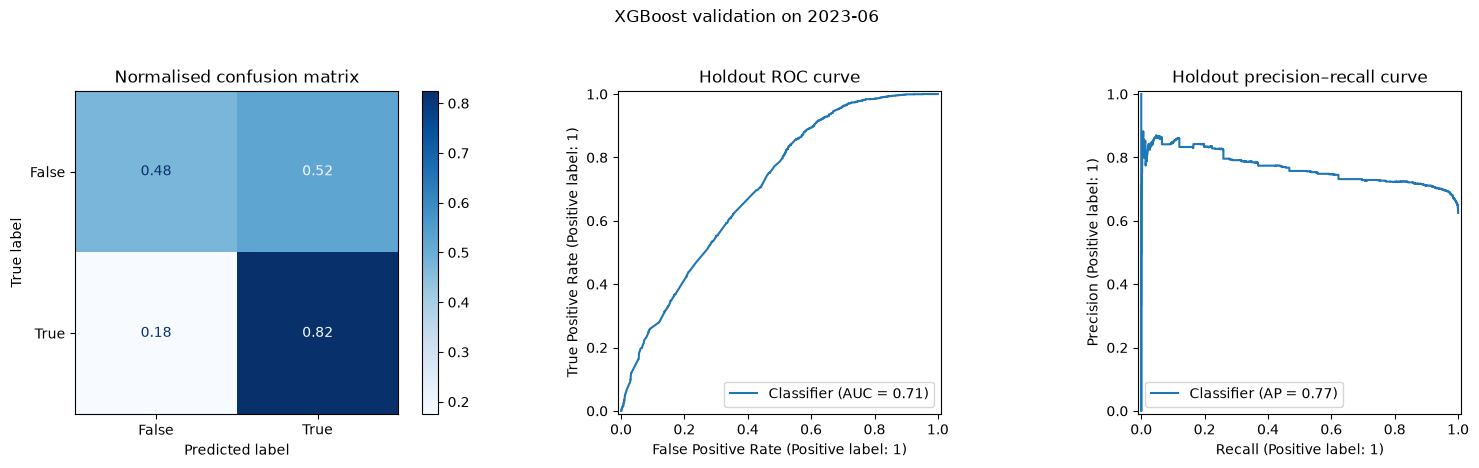

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    holdout_prediction,
    normalize="true",
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Normalised confusion matrix")

RocCurveDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    ax=axes[1],
)
axes[1].set_title("Holdout ROC curve")

PrecisionRecallDisplay.from_predictions(
    y_holdout,
    holdout_probability,
    ax=axes[2],
)
axes[2].set_title("Holdout precision–recall curve")

fig.suptitle(f"XGBoost validation on {holdout_fold.validation_period}", y=1.03)
fig.tight_layout()
plt.show()

### Holdout interpretation

The holdout result should be interpreted together with the train-minus-holdout gap. A modest decrease is expected; a very large ROC-AUC or average-precision gap would indicate that the selected XGBoost configuration fits historical customers much better than the future cohort. This table and the fold-level tuning diagnostics should be discussed explicitly in the final conclusions.

## 5. Refit on all labelled customers

The one-time holdout evaluation is now complete. The same frozen pipeline is rebuilt and fitted on every available labelled customer. Loading the unlabelled validation set at this point cannot change the selected model, parameters, or threshold.

In [8]:
prepared = prepare_modeling_data(DATA_DIR)

assert prepared.X_train.index.equals(training.X_train.index)
assert prepared.y_train.index.equals(training.y_train.index)
assert prepared.X_train.columns.tolist() == prepared.X_validation.columns.tolist()

final_model = make_model_pipeline(
    prepared.X_train,
    "xgboost",
    configuration.parameters,
)
final_model.fit(prepared.X_train, prepared.y_train)

print(f"Training customers: {len(prepared.X_train):,}")
print(f"Validation customers: {len(prepared.X_validation):,}")
print(f"Model features: {prepared.X_train.shape[1]:,}")

Training customers: 22,673
Validation customers: 11,590
Model features: 68


## 6. Predict validation churn

The model probability is converted into the required binary classification using the threshold selected on the tuning folds. Probabilities are retained only in memory for diagnostics and are not included in the submission.

In [9]:
validation_probability = positive_class_probability(
    final_model,
    prepared.X_validation,
)
validation_prediction = validation_probability.ge(configuration.threshold)

submission = pd.DataFrame(
    {
        CUSTOMER_ID_COLUMN: prepared.X_validation.index.to_numpy(),
        "Predictions": validation_prediction.to_numpy(dtype=bool),
    }
)
display(submission.head())

,FK_DWH_CUSTOMERS,Predictions
0,4068,True
1,7263,False
2,13310,False
3,17953,False
4,19548,False


## 7. Validate and save the deliverables

In [10]:
expected_columns = [CUSTOMER_ID_COLUMN, "Predictions"]

assert submission.columns.tolist() == expected_columns
assert len(submission) == len(prepared.X_validation)
assert submission[CUSTOMER_ID_COLUMN].is_unique
assert not bool(submission.isna().any().any())
assert set(submission["Predictions"].unique()) <= {True, False}
assert bool(validation_probability.between(0.0, 1.0).all())

prediction_summary = pd.Series(
    {
        "customers": len(submission),
        "predicted_churners": int(submission["Predictions"].sum()),
        "predicted_churn_rate": float(submission["Predictions"].mean()),
        "mean_churn_probability": float(validation_probability.mean()),
        "threshold": configuration.threshold,
    },
    name="validation_predictions",
)
display(prediction_summary.to_frame())

,validation_predictions
customers,"11,590.0000"
predicted_churners,"8,351.0000"
predicted_churn_rate,0.7205
mean_churn_probability,0.6176
threshold,0.6000


In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_PATH = OUTPUT_DIR / "predictions.csv"
MODEL_PATH = FINAL_ARTIFACT_DIR / "xgboost_pipeline.joblib"
HOLDOUT_METRICS_PATH = FINAL_ARTIFACT_DIR / "holdout_metrics.csv"
METADATA_PATH = FINAL_ARTIFACT_DIR / "metadata.json"

submission.to_csv(PREDICTIONS_PATH, index=False)
joblib.dump(final_model, MODEL_PATH)
metrics_table.to_csv(HOLDOUT_METRICS_PATH, index_label="sample")

metadata = {
    "schema_version": 1,
    "model_name": "xgboost",
    "configuration_path": str(CONFIG_PATH),
    "parameters": configuration.parameters,
    "threshold": configuration.threshold,
    "holdout_period": str(holdout_fold.validation_period),
    "holdout_metrics": json.loads(
        pd.DataFrame([holdout_metrics]).to_json(orient="records")
    )[0],
    "training_customers": len(prepared.X_train),
    "validation_customers": len(prepared.X_validation),
    "predicted_churners": int(validation_prediction.sum()),
    "predicted_churn_rate": float(validation_prediction.mean()),
    "cleaning_report": (
        prepared.cleaning_report.as_dict()
        if prepared.cleaning_report is not None
        else None
    ),
}
METADATA_PATH.write_text(
    json.dumps(metadata, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

print(f"Predictions: {PREDICTIONS_PATH}")
print(f"Fitted pipeline: {MODEL_PATH}")
print(f"Holdout metrics: {HOLDOUT_METRICS_PATH}")
print(f"Metadata: {METADATA_PATH}")

Predictions: /home/jordirm/dev/team-blue-assignment/outputs/predictions.csv
Fitted pipeline: /home/jordirm/dev/team-blue-assignment/artifacts/final/xgboost/xgboost_pipeline.joblib
Holdout metrics: /home/jordirm/dev/team-blue-assignment/artifacts/final/xgboost/holdout_metrics.csv
Metadata: /home/jordirm/dev/team-blue-assignment/artifacts/final/xgboost/metadata.json


In [12]:
# Final read-back check: validate the actual CSV written to disk.
saved_submission = pd.read_csv(PREDICTIONS_PATH)
assert saved_submission.columns.tolist() == expected_columns
assert len(saved_submission) == len(submission)
assert saved_submission[CUSTOMER_ID_COLUMN].is_unique
assert set(saved_submission["Predictions"].unique()) <= {True, False}

display(saved_submission.head())
print(f"Submission validated: {len(saved_submission):,} unique customers.")

,FK_DWH_CUSTOMERS,Predictions
0,4068,True
1,7263,False
2,13310,False
3,17953,False
4,19548,False


Submission validated: 11,590 unique customers.
